### Installing the scikit-fuzzy library to implement fuzzy logic

In [2]:
! pip install scikit-fuzzy 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 2.4 MB/s eta 0:00:000m eta -:--:--


### Importing the libraries

In [5]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

### Defining the Linguistic variable for antecedents/consequents

In [8]:
funding = ctrl.Antecedent(np.arange(0, 101, 1), "funding")
staffing = ctrl.Antecedent(np.arange(0,101,1), "staffing")
risk = ctrl.Consequent(np.arange(0,101,1), "risk")

### Defining the membership functions for each linguistic Variable

In [14]:
funding["inadequate"] = fuzz.trapmf(funding.universe, [0,0,30,45])
funding["marginal"] = fuzz.trimf(funding.universe, [30, 50, 70])
funding["adequate"] = fuzz.trapmf(funding.universe, [55, 70, 100, 100])

In [18]:
staffing["small"] = fuzz.trapmf(staffing.universe, [0,0,25,65])
staffing["large"] = fuzz.trapmf(staffing.universe, [35, 75, 100, 100])

In [20]:
risk['low'] = fuzz.trapmf(risk.universe, [0, 0, 20, 40])
risk['normal'] = fuzz.trapmf(risk.universe, [25, 45, 55, 75])
risk['high'] = fuzz.trapmf(risk.universe, [60, 80, 100, 100])

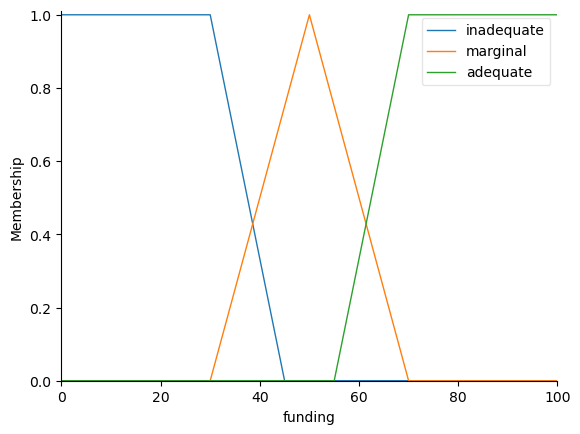

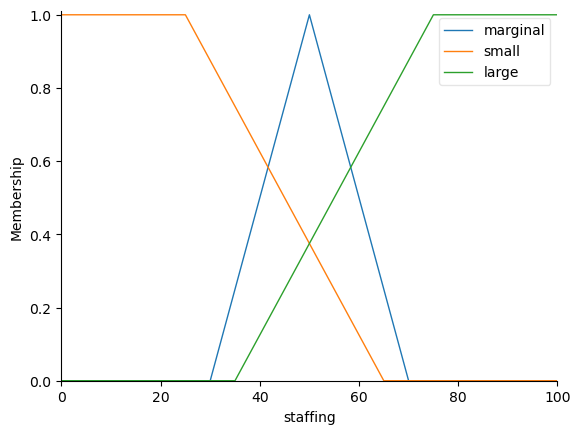

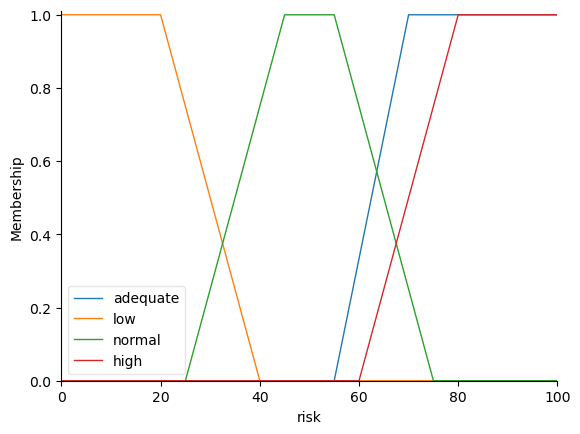

In [26]:
funding.view()
staffing.view()
risk.view()

### Defining the Rules

In [29]:
rule1 = ctrl.Rule(funding['adequate'] | staffing['small'], risk['low'])
rule2 = ctrl.Rule(funding['marginal'] & staffing['large'], risk['normal'])
rule3 = ctrl.Rule(funding['inadequate'], risk['high'])

### Build the systems from rules

In [32]:
ctrl_sys = ctrl.ControlSystem([rule1,rule2,rule3])

In [34]:
ctrl_sim = ctrl.ControlSystemSimulation(ctrl_sys)

### use the control system to asses project risk

In [37]:
ctrl_sim.inputs({"funding":35, "staffing":60})

In [41]:
# crunch the output
ctrl_sim.compute()

In [ ]:
print("Project risk:", ctrl_sim.output['risk'], "%")
risk.view(sim=ctrl_sim)